# Install Triton and verify installation

In [1]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [2]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [3]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# Dropout

- Seeded approach instead of passing mask
- Uses pseudo-random number generation

### Kernel and Wrapper

In [4]:
@triton.jit
def dropout_kernel(
    x_ptr,
    output_ptr,
    keep_mask_ptr,
    n_elements,
    p, # Dropout probability
    seed, # Seed for triton
    BLOCK_SIZE: tl.constexpr,
):
    # 1D program id
    pid = tl.program_id(axis=0)
    
    # Compute start position and offset
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)

    # Mask for out-of-bound
    mask = offsets < n_elements

    # Load input
    x = tl.load(x_ptr + offsets, mask=mask, other=0.0)

    # Generate a block of uniformly distributed values in [0, 1)
    random = tl.rand(seed, offsets)

    # Prune the generated random values based on dropout probability p
    x_keep = random > p

    # Apply the keep mask to x and divide x by (1 - p)
    output = tl.where(x_keep, x / (1 - p), 0.0)

    # Store output and keep mask
    tl.store(output_ptr + offsets, value=output, mask=mask)
    tl.store(keep_mask_ptr + offsets, value=x_keep, mask=mask)
    

def dropout(x, p, seed):
    # Input dimens
    n_rows, n_cols = x.shape
    
    # Allocate output
    output = torch.empty_like(x)
    keep_mask = torch.empty_like(x)

    # Define launch grid
    n_elements = x.numel()
    grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)

    # Call kernel
    dropout_kernel[grid](x, output, keep_mask, n_elements, p, seed, BLOCK_SIZE=1024)

    return output, keep_mask

### Test and Benchmark Helpers

In [5]:
def test_dropout_kernel(size: tuple, p: float, seed: int, atol=1e-6, rtol=1e-5, device=DEVICE):
    torch.manual_seed(seed)

    assert isinstance(size, tuple) and len(size) == 2

    m, n = size
    x = torch.randn(m, n, device=device)

    def ref_from_mask(x, keep_mask, p):
        keep_mask = keep_mask.bool()
        return torch.where(keep_mask, x / (1 - p), torch.zeros_like(x))

    output_triton, keep_mask = dropout(x, p, seed)
    output_ref = ref_from_mask(x, keep_mask, p)

    torch.testing.assert_close(output_triton, output_ref, atol=atol, rtol=rtol)
    print("Passed")


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=[128 * i for i in range(1, 100)],
        x_log=True,
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"],
        styles=[("blue", "-"), ("red", "-")],
        ylabel="GB/s",
        plot_name="dropout-performance",
        args={"M": 4096, "p": 0.2, "seed": 42},
    )
)
def benchmark(M, N, p, seed, provider):
    torch.manual_seed(seed)
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
    quantiles = [0.15, 0.5, 0.85]

    if provider == "torch":
        min_ms, ms, max_ms = triton.testing.do_bench(
            lambda: torch.nn.functional.dropout(x, p, training=True),
            quantiles=quantiles,
        )
    elif provider == "triton":
        min_ms, ms, max_ms = triton.testing.do_bench(
            lambda: dropout(x, p, seed)[0],
            quantiles=quantiles,
        )

    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(min_ms), gbps(ms), gbps(max_ms)

## Test

In [6]:
test_dropout_kernel((1025, 4100), p=0.3, seed=42)
test_dropout_kernel((2048, 4096), p=0.3, seed=42)

Passed
Passed


## Benchmark

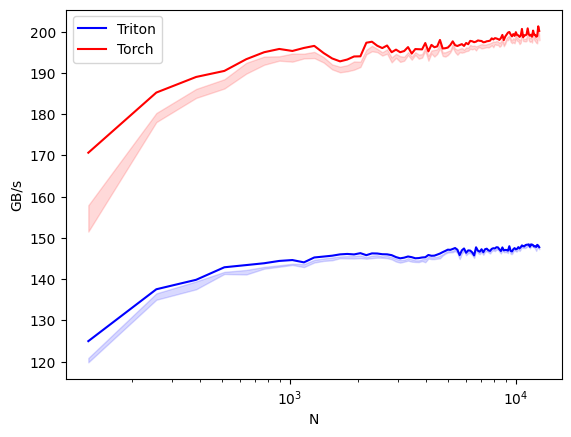

dropout-performance:
          N      Triton       Torch
0     128.0  124.949481  170.666661
1     256.0  137.536204  185.260784
2     384.0  139.834993  189.046153
3     512.0  142.871391  190.511628
4     640.0  143.404818  193.355758
5     768.0  143.848110  195.047621
6     896.0  144.411496  195.838632
7    1024.0  144.625187  195.352853
8    1152.0  144.064188  196.085101
9    1280.0  145.248230  196.586374
10   1408.0  145.469517  194.849925
11   1536.0  145.682772  193.535618
12   1664.0  145.999932  192.831471
13   1792.0  146.105760  193.278771
14   1920.0  145.990262  194.015941
15   2048.0  146.295920  194.054963
16   2176.0  145.808521  197.349512
17   2304.0  146.239472  197.595986
18   2432.0  146.212287  196.619900
19   2560.0  146.037969  196.052684
20   2688.0  146.012171  196.677541
21   2816.0  145.812300  195.047621
22   2944.0  145.339266  195.675567
23   3072.0  145.044637  195.047621
24   3200.0  145.204456  195.337142
25   3328.0  145.486342  196.294118
26   34

In [7]:
benchmark.run(print_data=True, show_plots=True)

# Scratch

In [8]:
@triton.jit
def rand_kernel(out_ptr, n_elements, seed, BLOCK_SIZE: tl.constexpr):
    p = 0.5
    pid = tl.program_id(0)
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements
    
    # Triton random numbers in [0, 1)
    random = tl.rand(seed, offsets)
    keep_mask = random > p
    output = tl.where(keep_mask, random, 0.0)
    
    tl.store(out_ptr + offsets, output, mask=mask)


def test_triton_rand(n_elements=10, seed=42):
    out = torch.empty(n_elements, device="cuda", dtype=torch.float32)

    grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)

    rand_kernel[grid](
        out,
        n_elements,
        seed,
        BLOCK_SIZE=1024,
    )

    print(out)
    return out

x = test_triton_rand()

tensor([0.7741, 0.0000, 0.0000, 0.5408, 0.6528, 0.6297, 0.0000, 0.7167, 0.9040,
        0.5327], device='cuda:0')
